<a href="https://colab.research.google.com/github/emanuelmejia/course_time_series_python/blob/main/X-Challenge/Challenge_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data management
import numpy as np
import pandas as pd

# DataViz
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

In [2]:
# Subir archivo productos
from google.colab import files
files.upload()

Saving productos.csv to productos (4).csv


{'productos (4).csv': b'date,category,subcategory,key,description,qty,unitPrice,subtotal,total\n2023-09-01,BEBIDAS CALIENTES,COFFEE,1001,AMERICANO CHIBI,26,34.48,896.56,1040.0\n2023-09-01,BEBIDAS FRIAS,COFFEE,2003,COLD AMERICANO CUPHEAD,10,50.0,500.0,580.0\n2023-09-01,BEBIDAS FRIAS,COFFEE,2001,COLD AMERICANO CHIBI,10,24.14,241.38,280.0\n2023-09-01,BEBIDAS FRIAS,COFFEE,2004,LATTE FRIO,6,43.1,258.62,300.0\n2023-09-01,BEBIDAS CALIENTES,COFFEE,1003,AMERICANO CUPHEAD,4,43.1,172.42,200.0\n2023-09-01,BEBIDAS FRIAS,FRAPPES,2005,MALTEADA,2,64.66,129.32,150.0\n2023-09-01,BEBIDAS FRIAS,COFFEE,2002,COLD AMERICANO CLUB,2,30.17,60.34,70.0\n2023-09-01,BEBIDAS CALIENTES,COFFEE,1009,CAFE CON LECHE,2,34.48,68.96,80.0\n2023-10-01,MODIFICADORES,LECHE,99001,L1-LECHE LIGHT,122,1.72,210.34,208.8\n2023-10-01,ALIMENTOS,ENTSALADITAS,3002,ENTSALADITA TSIBI,68,50.86,3458.62,3268.34\n2023-10-01,ALIMENTOS,DESSERTS,3501,REBANADA DE PANQUE,46,17.24,793.1,755.4\n2023-10-01,ALIMENTOS,MOLLETSIBI,3004,MOLLEPIZZA PEPPERON

In [3]:
dfProd = pd.read_csv("/content/productos.csv", encoding='latin1')
dfProd['date'] = pd.to_datetime(dfProd['date'])
dfProd = dfProd.set_index('date')

In [4]:
# Agrupar ventas mensuales por categoría
dfCat = dfProd.groupby(['date', 'category'])['total'].sum().reset_index()

# rellenar categorías-meses con ventas 0
all_dates = pd.date_range(start=dfCat['date'].min(), end=dfCat['date'].max(), freq='MS')
all_categories = dfCat['category'].unique()
full_index = pd.MultiIndex.from_product([all_dates, all_categories], names=['date', 'category'])
full_df = pd.DataFrame(index=full_index).reset_index()
dfCat = pd.merge(full_df, dfCat, on=['date', 'category'], how='left')
dfCat['total'] = dfCat['total'].fillna(0)

dfCat = dfCat.set_index('date')

dfCat.head(10)

,category,total
date,,
2023-09-01,BEBIDAS CALIENTES,1320.00
2023-09-01,BEBIDAS FRIAS,1380.00
2023-09-01,ALIMENTOS,0.00
2023-09-01,MODIFICADORES,0.00
2023-09-01,PAQUETES,0.00
2023-09-01,PROMOCIONALES,0.00
2023-10-01,BEBIDAS CALIENTES,14684.28
2023-10-01,BEBIDAS FRIAS,10973.00
2023-10-01,ALIMENTOS,13039.60


In [5]:
# Agrupar ventas mensuales totales
df = dfCat.groupby('date')['total'].sum().reset_index()
df = df.set_index('date')

df.head()

,total
date,
2023-09-01,2700.00
2023-10-01,39016.04
2023-11-01,43017.20
2023-12-01,33834.82
2024-01-01,37582.90


In [6]:
# Font para etiquetas y títulos
fontEti = {'family':'serif','color':'cornflowerblue','size': 18, 'fontweight': 'bold'}
fontTit = {'family':'serif','color':'cornflowerblue','size': 25, 'fontweight': 'bold'}

# Formato de moneda para ticks
fmoneda = '${x:,.0f}'
tick = mtick.StrMethodFormatter(fmoneda)

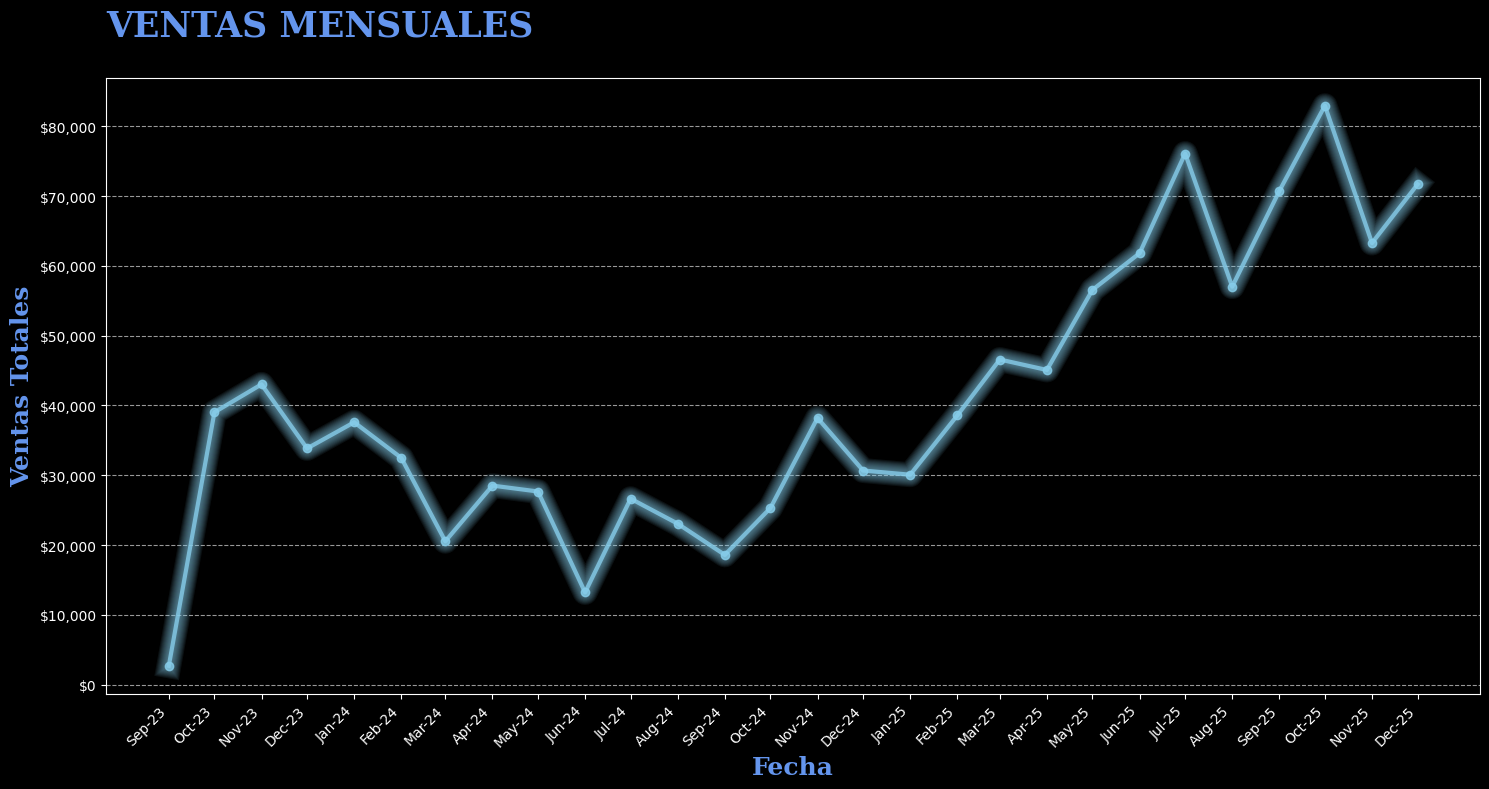

In [7]:
#  Aplicar background
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(15, 8))

# Parámetros para línea brillante
base_color = 'skyblue'
n_glows = 10
base_linewidth = 3
base_opacity = 0.8

# Graficar varias veces para dar efecto de brillo
for i in range(1, n_glows + 1):
    ax.plot(df.index,
            df['total'],
            color=base_color,
            linewidth=base_linewidth + (i * 1.5),
            alpha=base_opacity / n_glows)

# Graficar la línea principal encima
ax.plot(df.index,
        df['total'],
        marker='o',
        linewidth= base_linewidth,
        color=base_color,
        alpha=base_opacity)


# Etiquetas
ax.set_title('VENTAS MENSUALES', fontdict=fontTit, loc='left', pad=30)
ax.set_xlabel('Fecha', fontdict=fontEti)
ax.set_ylabel('Ventas Totales', fontdict=fontEti)
ax.set_xticks(df.index) # Pedir explícitamente las etiquetas de x
ax.set_xticklabels(df.index.strftime('%b-%y'), rotation=45, ha='right')
ax.yaxis.set_major_formatter(tick) # Aplicar formato de moneda en x

# Formato al enrejado del gráfico
ax.grid(False, axis = 'x')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# **Ejercicio final**

Ajusta un modelo a las ventas totales por mes y elabora un pronóstico para los siguientes 6 meses (Ene26-Jun26)